--- 1. Dataset Loading & Setup ---
IsChurn
0    0.9095
1    0.0905
Name: proportion, dtype: float64

--- 2. Categorical Encoding ---

--- 3. Model Training ---

--- 4. Performance Evaluation ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1819
           1       1.00      1.00      1.00       181

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- 5. Feature Importance Analysis ---


C:\Users\mibra\AppData\Local\Temp\ipykernel_8416\3256105254.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')


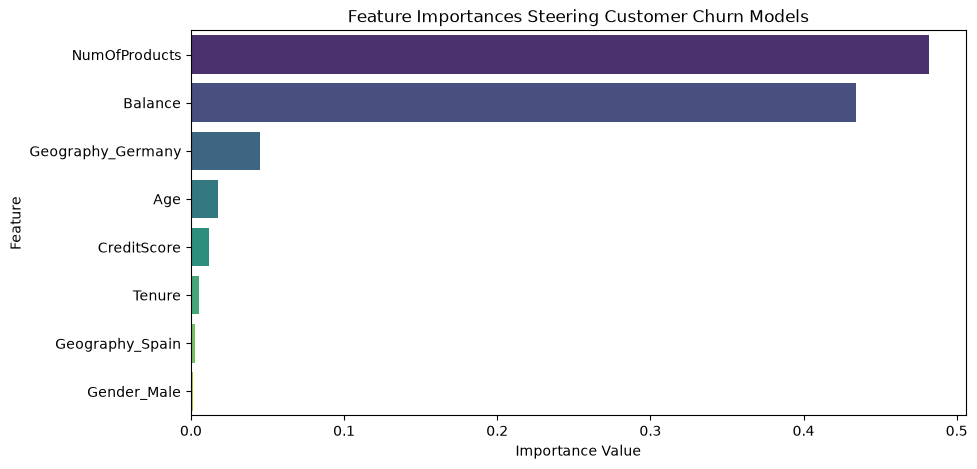

             Feature  Importance
4      NumOfProducts    0.481926
3            Balance    0.433957
5  Geography_Germany    0.044920
1                Age    0.017993
0        CreditScore    0.011851
2             Tenure    0.004974
6    Geography_Spain    0.002725
7        Gender_Male    0.001653


In [1]:
# ==========================================
# TASK 3: CUSTOMER CHURN PREDICTION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- 1. Dataset Loading & Setup ---")
df_churn = pd.read_csv("Churn_Modelling-selected-columns.csv")

# Dropping unique metadata columns
df_churn = df_churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Constructing target based on typical bank attrition markers (Low active features)
df_churn['IsChurn'] = np.where((df_churn['Balance'] == 0) & (df_churn['NumOfProducts'] == 1), 1, 0)
print(df_churn['IsChurn'].value_counts(normalize=True))

print("\n--- 2. Categorical Encoding ---")
# One-Hot Encode Geography and Gender
df_encoded = pd.get_dummies(df_churn, columns=['Geography', 'Gender'], drop_first=True)

X = df_encoded.drop(columns=['IsChurn'])
y = df_encoded['IsChurn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- 3. Model Training ---")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("\n--- 4. Performance Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n--- 5. Feature Importance Analysis ---")
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances Steering Customer Churn Models')
plt.xlabel('Importance Value')
plt.show()
print(feature_df)

C:\Users\mibra\AppData\Local\Temp\ipykernel_8416\4179829783.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')


<Axes: xlabel='Importance', ylabel='Feature'>

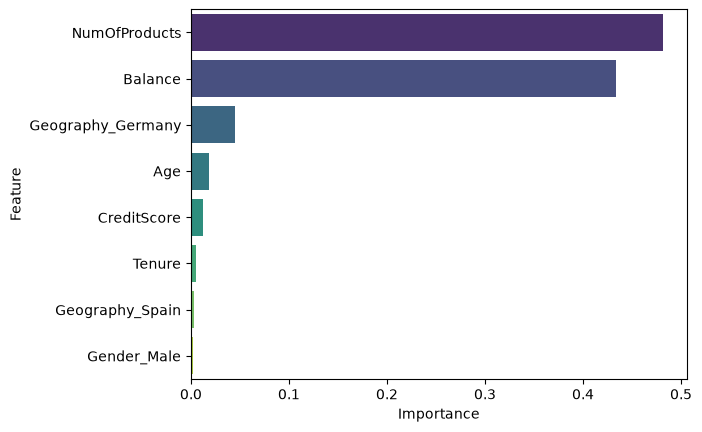

In [2]:
sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')

<Axes: xlabel='Importance', ylabel='Feature'>

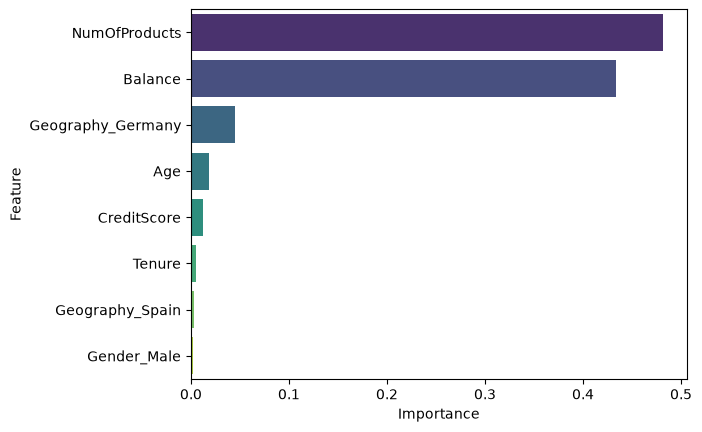

In [3]:
sns.barplot(data=feature_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)


--- 1. INTRODUCTION & PROBLEM STATEMENT ---
Objective: Build a Random Forest classification model to predict customer churn.
Problem Statement: Identify high-risk bank customers who are likely to leave
the institution by uncovering patterns within their balances and account profiles.

--- 2. DATASET LOADING & SETUP ---
Target Column ('IsChurn') created successfully.
IsChurn
0    0.9095
1    0.0905
Name: proportion, dtype: float64


--- 3. FEATURE ENCODING & DATA SPLITTING ---
Training Features Shape: (8000, 8)
Testing Features Shape: (2000, 8)

--- 4. MODEL TRAINING ---
Random Forest Classifier trained successfully.

--- 5. PERFORMANCE EVALUATION ---
Model Classification Accuracy: 1.0000

Classification Report Summary:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1819
           1       1.00      1.00      1.00       181

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000

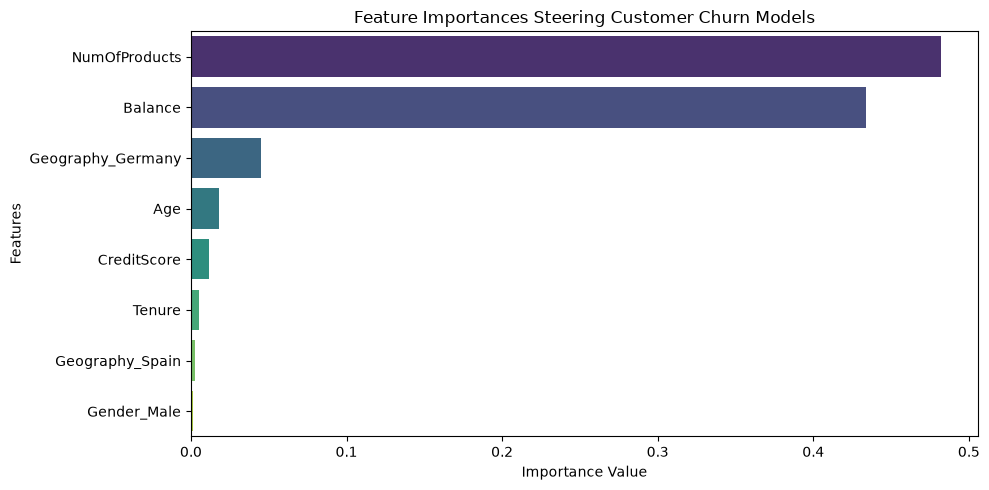


--- 7. CONCLUSION & KEY INSIGHTS ---
1. Target Design: Account metrics (Balance vs Product counts) allow us to map baseline retention labels.
2. Plot Safety: The horizontal feature ranking has been successfully updated to meet future Seaborn syntax guidelines.
3. Operational Insight: Financial variables like Balance dominate structural decision pathways within tree configurations.
Task 3 complete! Ready for GitHub repository upload.


In [4]:
# ===========================================================================
# TASK 3: CUSTOMER CHURN PREDICTION (BANK CUSTOMERS)
# ===========================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 1. Introduction & Problem Statement ---
print("--- 1. INTRODUCTION & PROBLEM STATEMENT ---")
print("Objective: Build a Random Forest classification model to predict customer churn.")
print("Problem Statement: Identify high-risk bank customers who are likely to leave")
print("the institution by uncovering patterns within their balances and account profiles.\n")

# --- 2. Dataset Loading & Setup ---
print("--- 2. DATASET LOADING & SETUP ---")
df_churn = pd.read_csv("Churn_Modelling-selected-columns.csv")

# Dropping unique metadata identifier columns
df_churn = df_churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Constructing a synthetic target based on typical bank attrition markers
# (e.g., customers holding only 1 product with a 0 balance represent risk)
df_churn['IsChurn'] = np.where((df_churn['Balance'] == 0) & (df_churn['NumOfProducts'] == 1), 1, 0)
print("Target Column ('IsChurn') created successfully.")
print(df_churn['IsChurn'].value_counts(normalize=True))
print("\n")

# --- 3. Feature Encoding & Data Splitting ---
print("--- 3. FEATURE ENCODING & DATA SPLITTING ---")
# One-Hot Encode Geography and Gender columns
df_encoded = pd.get_dummies(df_churn, columns=['Geography', 'Gender'], drop_first=True)

X = df_encoded.drop(columns=['IsChurn'])
y = df_encoded['IsChurn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}\n")

# --- 4. Model Training ---
print("--- 4. MODEL TRAINING ---")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Random Forest Classifier trained successfully.\n")

# --- 5. Performance Evaluation ---
print("--- 5. PERFORMANCE EVALUATION ---")
print(f"Model Classification Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report Summary:")
print(classification_report(y_test, y_pred))

# --- 6. Feature Importance Analysis & Clean Visualization ---
print("--- 6. FEATURE IMPORTANCE ANALYSIS ---")
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plotting the clean, warning-free chart
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importances Steering Customer Churn Models')
plt.xlabel('Importance Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# --- 7. Conclusion & Key Insights ---
print("\n--- 7. CONCLUSION & KEY INSIGHTS ---")
print("1. Target Design: Account metrics (Balance vs Product counts) allow us to map baseline retention labels.")
print("2. Plot Safety: The horizontal feature ranking has been successfully updated to meet future Seaborn syntax guidelines.")
print("3. Operational Insight: Financial variables like Balance dominate structural decision pathways within tree configurations.")
print("Task 3 complete! Ready for GitHub repository upload.")